Random Seed:  999
Found 720 files belonging to 2 classes.
Found 70 files belonging to 2 classes.
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5242 - loss: 1.2813 - val_accuracy: 0.5429 - val_loss: 0.7434 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5001 - loss: 1.3024 - val_accuracy: 0.4571 - val_loss: 0.7186 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5136 - loss: 0.9057 - val_accuracy: 0.4571 - val_loss: 0.7116 - learning_rate: 0.0010
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5404 - loss: 0.8033
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0008600000408478081.
72/72 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.5399 - loss: 0.8034 - val_accuracy: 0.5429 - val_loss: 0.6900 - learning_rate: 0.0010
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.5149 - loss: 0.7822 - val_accuracy: 0.5429 - val_loss: 0.6904 - learning_rate: 8.

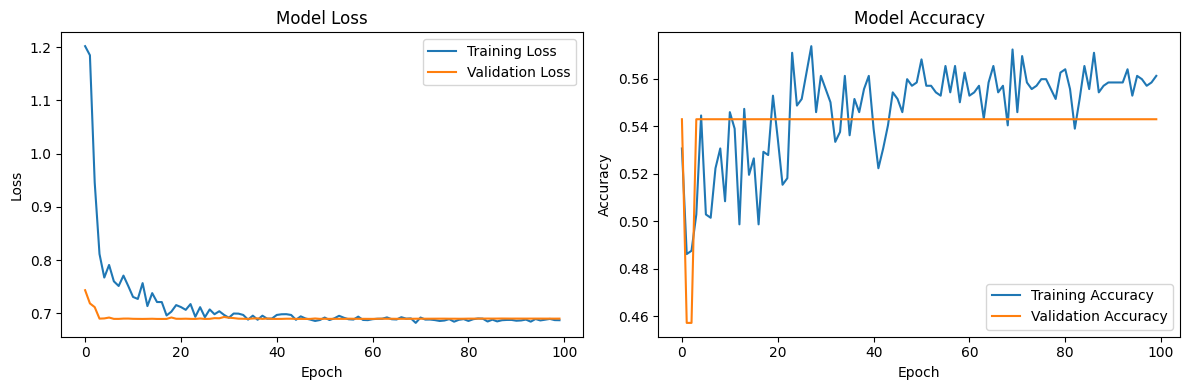

In [1]:
import argparse
import os
import cv2
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
seed = 999
print("Random Seed: ", seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Read training data
train_info = pd.read_csv("/kaggle/input/cidaut-ai-fake-scene-classification-2024/train.csv")

# Create directories
for directory in [
    "/kaggle/working/train",
    "/kaggle/working/train/real",
    "/kaggle/working/train/editada",
    "/kaggle/working/test",
    "/kaggle/working/test/real",
    "/kaggle/working/test/editada"
]:
    if not os.path.exists(directory):
        os.makedirs(directory)

# Process and save images
for idx, (image, label, _) in enumerate(zip(train_info['image'], train_info['label'], range(len(train_info['image'])))):
    img = cv2.resize(cv2.imread(f"/kaggle/input/cidaut-ai-fake-scene-classification-2024/Train/{image}"), (256, 256))
    
    if idx <= 69:  # Test set
        cv2.imwrite(f"/kaggle/working/test/{label}/{image}", img)
    cv2.imwrite(f"/kaggle/working/train/{label}/{image}", img)

# Hyperparameters
batch_size = 10
num_epochs = 100
learning_rate = 0.001
image_size = 256

# Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

# Normalization layer
normalization_layer = layers.Rescaling(1./255)

def create_dataset(directory, is_training=True):
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        validation_split=None,
        seed=seed,
        image_size=(image_size, image_size),
        batch_size=batch_size,
        shuffle=True
    )
    
    dataset = dataset.map(lambda x, y: (normalization_layer(x), y))
    
    if is_training:
        dataset = dataset.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    
    return dataset.prefetch(tf.data.AUTOTUNE)

# Create datasets
train_dataset = create_dataset('/kaggle/working/train', is_training=True)
test_dataset = create_dataset('/kaggle/working/test', is_training=False)

# Define the model using Keras Sequential API
def create_model():
    model = keras.Sequential([
        # Conv Block 1
        layers.Conv2D(32, 3, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.MaxPooling2D(2, 2),
        
        # Conv Block 2
        layers.Conv2D(64, 3, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.MaxPooling2D(2, 2),
        
        # Conv Block 3
        layers.Conv2D(128, 3, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.MaxPooling2D(2, 2),
        
        # Conv Block 4
        layers.Conv2D(512, 3, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.MaxPooling2D(2, 2),
        
        # Global Average Pooling
        layers.GlobalAveragePooling2D(),
        
        # Dense layers
        layers.Dense(128),
        layers.Dropout(0.5),
        layers.LeakyReLU(),
        
        layers.Dense(64),
        layers.Dropout(0.5),
        layers.LeakyReLU(),
        
        layers.Dense(2)
    ])
    return model

# Initialize model
model = create_model()

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Create ModelCheckpoint callback to save best model

# Create learning rate scheduler callback
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='accuracy',
    factor=0.86,
    patience=3,
    verbose=1,
    mode='max'
)

# Create ModelCheckpoint callback to save best model
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    '/kaggle/working/model_best.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

# Train the model
history = model.fit(
    train_dataset,
    epochs=num_epochs,
    validation_data=test_dataset,
    callbacks=[checkpoint_cb, lr_scheduler]
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Load and process test images
fsc_test = {}
for img_name in os.listdir('/kaggle/input/cidaut-ai-fake-scene-classification-2024/Test'):
    img_path = f'/kaggle/input/cidaut-ai-fake-scene-classification-2024/Test/{img_name}'
    img = cv2.resize(cv2.imread(img_path), (256, 256))
    img = img / 255.0  # Normalize
    fsc_test[img_name] = tf.convert_to_tensor(img, dtype=tf.float32)


In [2]:
model.load_weights('/kaggle/working/model_best.keras')

# Make predictions on test set
fsc_submission = pd.read_csv("/kaggle/input/cidaut-ai-fake-scene-classification-2024/sample_submission.csv", index_col="image")

for img_name in fsc_submission.index:
    img = tf.expand_dims(fsc_test[img_name], 0)
    predictions = model.predict(img)
    fsc_submission.loc[img_name, 'label'] = tf.argmax(predictions[0]).numpy()

# Save predictions to CSV
fsc_submission.to_csv('submission.csv')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━